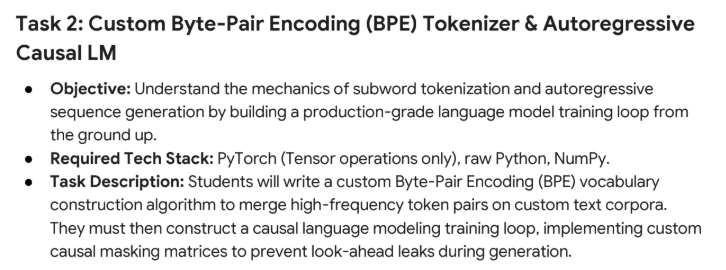

**Objective**


Build the basic components of a GPT-style language model

**Create a Small Training Corpus**

In [ ]:
text = """
robots learn tasks from language.
robots move objects.
robots pick objects.
robots place objects.
language controls robots.
the robot learns from instructions.
the robot moves to the table.
the robot picks the object.
the robot places the object.
"""

**Convert Text to Characters**

In [ ]:
text = text.lower()

tokens = list(text)

print(tokens[:50])

['\n', 'r', 'o', 'b', 'o', 't', 's', ' ', 'l', 'e', 'a', 'r', 'n', ' ', 't', 'a', 's', 'k', 's', ' ', 'f', 'r', 'o', 'm', ' ', 'l', 'a', 'n', 'g', 'u', 'a', 'g', 'e', '.', '\n', 'r', 'o', 'b', 'o', 't', 's', ' ', 'm', 'o', 'v', 'e', ' ', 'o', 'b', 'j']


**Count Adjacent Token Pairs**

In [ ]:
from collections import Counter

def get_pair_counts(tokens):
    pairs = Counter()

    for i in range(len(tokens) - 1):
        pair = (tokens[i], tokens[i + 1])
        pairs[pair] += 1

    return pairs

**Merge the Most Frequent Pair**

In [ ]:
def merge_pair(tokens, pair):
    merged = []
    i = 0

    while i < len(tokens):

        if i < len(tokens) - 1 and (
            tokens[i],
            tokens[i + 1]
        ) == pair:

            merged.append(
                tokens[i] + tokens[i + 1]
            )

            i += 2

        else:
            merged.append(tokens[i])
            i += 1

    return merged

**Train BPE Vocabulary**

In [ ]:
def train_bpe(tokens, num_merges=50):

    tokens = tokens.copy()
    merges = []

    for _ in range(num_merges):

        pair_counts = get_pair_counts(tokens)

        if not pair_counts:
            break

        best_pair, count = pair_counts.most_common(1)[0]

        if count < 2:
            break

        merges.append(best_pair)

        tokens = merge_pair(
            tokens,
            best_pair
        )

    vocabulary = sorted(set(tokens))

    return merges, vocabulary

In [ ]:
merges, vocabulary = train_bpe(
    tokens,
    num_merges=30
)

print("Number of merges:", len(merges))
print("Vocabulary size:", len(vocabulary))

Number of merges: 30
Vocabulary size: 38


**Create Token IDs**

In [ ]:
special_tokens = [
    "<PAD>",
    "<UNK>"
]

vocab = special_tokens + vocabulary

stoi = {
    token: idx
    for idx, token in enumerate(vocab)
}

itos = {
    idx: token
    for token, idx in stoi.items()
}

print("Vocabulary:")
print(stoi)

Vocabulary:
{'<PAD>': 0, '<UNK>': 1, '\n': 2, ' ': 3, '.\n': 4, 'a': 5, 'b': 6, 'c': 7, 'ct': 8, 'e': 9, 'e ': 10, 'from ': 11, 'g': 12, 'i': 13, 'k': 14, 'ks ': 15, 'l': 16, 'la': 17, 'lan': 18, 'le': 19, 'learn': 20, 'm': 21, 'n': 22, 'o': 23, 'object': 24, 'objects.\n': 25, 'p': 26, 'r': 27, 'ro': 28, 'robot': 29, 'robots ': 30, 's': 31, 's ': 32, 's.\n': 33, 't': 34, 'ta': 35, 'the ': 36, 'the robot ': 37, 'u': 38, 'v': 39}


**BPE Encoding**

In [ ]:
def apply_bpe(text, merges):

    tokens = list(text.lower())

    for pair in merges:
        tokens = merge_pair(
            tokens,
            pair
        )

    return tokens

**Encoder**

In [ ]:
def encode(text):

    tokens = apply_bpe(
        text,
        merges
    )

    ids = []

    for token in tokens:

        if token in stoi:
            ids.append(stoi[token])
        else:
            ids.append(stoi["<UNK>"])

    return ids

In [ ]:
sentence = "robot moves"

encoded = encode(sentence)

print("Text:", sentence)
print("Encoded:", encoded)

Text: robot moves
Encoded: [29, 3, 21, 23, 39, 9, 31]


**Decoder**

In [ ]:
def decode(ids):

    tokens = []

    for idx in ids:

        if idx in itos:
            tokens.append(itos[idx])

    return "".join(tokens)

In [ ]:
decoded = decode(encoded)
print("Decoded:", decoded)

Decoded: robot moves


**Build Training Sequences**

In [ ]:
import torch

data = torch.tensor(
    encode(text),
    dtype=torch.long
)

print("Dataset shape:", data.shape)

Dataset shape: torch.Size([95])


**Create Input/Target Pairs**

In [ ]:
block_size = 32

x = data[:block_size]
y = data[1:block_size + 1]

print("Input:")
print(x)

print("\nTarget:")
print(y)

Input:
tensor([ 2, 30, 20,  3, 35, 31, 15, 11, 18, 12, 38,  5, 12,  9,  4, 30, 21, 23,
        39, 10, 25, 30, 26, 13,  7, 14,  3, 25, 30, 26, 17,  7])

Target:
tensor([30, 20,  3, 35, 31, 15, 11, 18, 12, 38,  5, 12,  9,  4, 30, 21, 23, 39,
        10, 25, 30, 26, 13,  7, 14,  3, 25, 30, 26, 17,  7, 10])


**Build a Small Causal Transformer**

In [ ]:
import torch.nn as nn

import torch.nn.functional as F

In [ ]:
class CausalLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        num_heads=4,
        num_layers=2,
        block_size=32
    ):

        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embedding_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.output_layer = nn.Linear(
            embedding_dim,
            vocab_size
        )

        self.block_size = block_size

    def forward(self, x):

        B, T = x.shape

        positions = torch.arange(
            T,
            device=x.device
        )

        token_embeddings = self.token_embedding(x)

        position_embeddings = self.position_embedding(
            positions
        )

        h = token_embeddings + position_embeddings

        # Causal look-ahead mask
        mask = torch.triu(
            torch.ones(
                T,
                T,
                device=x.device
            ),
            diagonal=1
        ).bool()

        h = self.transformer(
            h,
            mask=mask
        )

        logits = self.output_layer(h)

        return logits

**Initialize Model**

In [ ]:
vocab_size = len(vocab)

model = CausalLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_heads=4,
    num_layers=2,
    block_size=block_size
)

print(model)

CausalLanguageModel(
  (token_embedding): Embedding(40, 128)
  (position_embedding): Embedding(32, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=128, out_features=40, bias=True)
)


**Training Loop**

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001
)

loss_history = []

epochs = 300

In [ ]:
for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(
        x.unsqueeze(0)
    )

    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        y.view(-1)
    )

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )
    if epoch % 50 == 0:
        print(
            f"Epoch {epoch} | Loss: {loss.item():.4f}"
        )

Epoch 0 | Loss: 3.7407
Epoch 50 | Loss: 0.0144
Epoch 100 | Loss: 0.0067
Epoch 150 | Loss: 0.0042
Epoch 200 | Loss: 0.0029
Epoch 250 | Loss: 0.0021


In [ ]:
loss_history = []

epochs = 300

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    logits = model(x.unsqueeze(0))

    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        y.view(-1)
    )

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 0.0016
Epoch 50 | Loss: 0.0013
Epoch 100 | Loss: 0.0011
Epoch 150 | Loss: 0.0009
Epoch 200 | Loss: 0.0007
Epoch 250 | Loss: 0.0006


**Plot Training Loss**

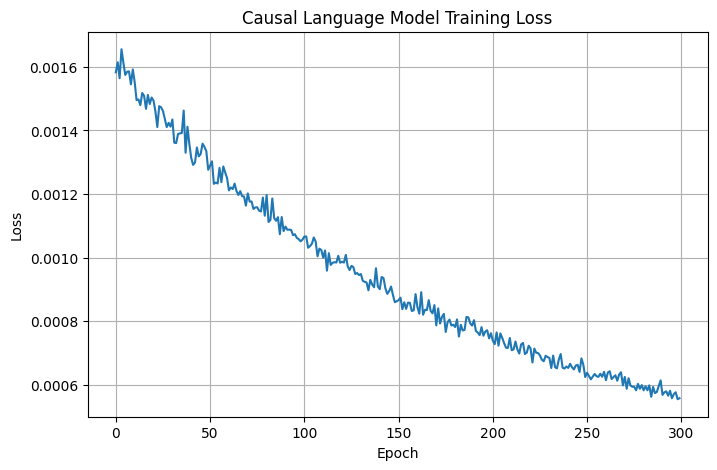

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Causal Language Model Training Loss")

plt.grid()

plt.show()

**Autoregressive Generation**

In [ ]:
def generate(
    model,
    input_ids,
    max_new_tokens=20
):

    model.eval()

    generated = input_ids.clone()

    for _ in range(max_new_tokens):

        context = generated[
            :, -block_size:
        ]

        logits = model(context)

        next_token_logits = logits[:, -1, :]

        probabilities = F.softmax(
            next_token_logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        generated = torch.cat(
            [generated, next_token],
            dim=1
        )

    return generated

**Generate Text**

In [ ]:
prompt = "robot"

prompt_ids = torch.tensor(
    [encode(prompt)],
    dtype=torch.long
)

generated_ids = generate(
    model,
    prompt_ids,
    max_new_tokens=20
)

generated_text = decode(
    generated_ids[0].tolist()
)

print("Generated text:")
print(generated_text)

Generated text:
robotrobots learn tasks from language.
robots move objects.



**Complete Architecture**

                 TRAINING
                    │
                    ▼
              Raw Text Corpus
                    │
                    ▼
            Custom BPE Tokenizer
                    │
                    ▼
               Token IDs
                    │
                    ▼
            Token Embeddings
                    +
            Position Embeddings
                    │
                    ▼
          Causal Transformer
                    │
                    ▼
                 Logits
                    │
                    ▼
              Cross Entropy
                    │
                    ▼
             Backpropagation
                    │
                    ▼
              Updated Model


                 INFERENCE
                    │
                    ▼
                  Prompt
                    │
                    ▼
               BPE Tokens
                    │
                    ▼
             Transformer
                    │
                    ▼
            Next Token Logits
                    │
                    ▼
              Sampling
                    │
                    ▼
              Next Token
                    │
                    └───────────┐
                                │
                                ▼
                         Repeat Generation